# CNN-LSTM with Hyperparameter Optimization — Many-to-One Energy Price Forecasting

This notebook takes the CNN-LSTM architecture from `04_cnn_lstm_energy_forecasting.ipynb`
and **searches** over its hyperparameters instead of guessing them by hand,
using [Keras Tuner](https://keras.io/keras_tuner/). Same dataset, same
many-to-one task, so the baseline and tuned results here are directly
comparable to both `02_lstm_energy_forecasting.ipynb` and `04_cnn_lstm_energy_forecasting.ipynb`.

## 1. Why hyperparameter optimization?

`FILTERS`, `KERNEL_SIZE`, `POOL_SIZE`, `UNITS`, and the learning rate all
interact — a wider `Conv1D` might need a different learning rate to train
well, more `LSTM` units might need dropout to avoid overfitting, and so on.
Hand-picking one value per hyperparameter (as the baseline notebook does)
explores exactly one point in a large, interacting search space. This
notebook instead defines a **search space** (a range or a set of choices per
hyperparameter) and lets an automated **search strategy** sample multiple
combinations, train each briefly, and keep the one with the best validation
loss.

**Search strategies, briefly:**
- **Grid search** — tries every combination; thorough but explodes combinatorially.
- **Random search** — samples combinations at random; often finds a good
  region of the space far faster than grid search for the same budget. This
  notebook uses `keras_tuner.RandomSearch`.
- **Bayesian / Hyperband** — use the results of earlier trials to choose the
  next combination more intelligently (Keras Tuner also ships `BayesianOptimization`
  and `Hyperband` — swap in either as a drop-in replacement for `RandomSearch`
  below to compare).

This notebook keeps the search small (`MAX_TRIALS = 8`, `SEARCH_EPOCHS = 20`)
so it finishes in a few minutes — increase both for a more thorough (and much
slower) search on your own machine.

## 1b. Setup and Imports

Model architecture diagrams (`show_model_diagram`) need `pydot` and the Graphviz `dot` executable. If missing, those cells print a note and skip the diagram — everything else still runs.
```bash
pip install pydot
sudo apt-get install graphviz   # Debian/Ubuntu
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100

## 2. Dataset: Hourly Energy Demand, Generation, Price & Weather (Spain)

**Source:** [Hourly Energy Demand, Generation, Weather and Price — Kaggle](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)
(`nicholasjhana/energy-consumption-generation-prices-and-weather`)

This is the same dataset and the same many-to-one task (24 hours of history ->
next-hour price) used in the companion `01_vanilla_rnn`, `02_lstm`, and
`03_gru` notebooks, so results here are directly comparable to those.

**To use the real dataset**, do ONE of:

1. **Kaggle CLI** (needs a Kaggle account + API token at `~/.kaggle/kaggle.json`):
   ```bash
   pip install kaggle
   kaggle datasets download -d nicholasjhana/energy-consumption-generation-prices-and-weather -p data --unzip
   ```
2. **Manual download**: download `energy_dataset.csv` from the Kaggle page above and place it at `./data/energy_dataset.csv`.
3. **kagglehub** (cell below will try this automatically if installed and authenticated).

If none of the above is available, the loader below **falls back to a synthetic
dataset** with the same column names and realistic daily/weekly seasonality, so
every cell in this notebook still runs end-to-end without the real file.

In [3]:
!pip install -q -U kagglehub

import os
import shutil
from google.colab import drive, userdata

drive.mount("/content/drive")

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/access_token"), "w") as f:
    f.write(os.environ["KAGGLE_API_TOKEN"])
os.chmod(os.path.expanduser("~/.kaggle/access_token"), 0o600)

DRIVE_CSV = "/content/drive/MyDrive/energy_data/energy_dataset.csv"
os.makedirs("data", exist_ok=True)

if os.path.exists(DRIVE_CSV):
    shutil.copy(DRIVE_CSV, "data/energy_dataset.csv")
    print("Copied from Google Drive")
else:
    import kagglehub
    path = kagglehub.dataset_download("nicholasjhana/energy-consumption-generation-prices-and-weather")
    shutil.copy(os.path.join(path, "energy_dataset.csv"), "data/energy_dataset.csv")
    os.makedirs(os.path.dirname(DRIVE_CSV), exist_ok=True)
    shutil.copy("data/energy_dataset.csv", DRIVE_CSV)
    print("Downloaded from Kaggle and saved a backup to Google Drive")

print(os.listdir("data"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied from Google Drive
['energy_dataset.csv']


In [4]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"
ENERGY_CSV = os.path.join(DATA_DIR, "energy_dataset.csv")

FEATURE_COLS = [
    "total load actual",
    "generation solar",
    "generation wind onshore",
    "generation fossil gas",
    "price actual",
]
TARGET_COL = "price actual"


def _make_synthetic_energy_data(n_hours: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Stand-in dataset with the same schema/units as energy_dataset.csv, built
    from daily + weekly seasonal components plus noise, so the notebook can run
    fully offline without Kaggle credentials."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2018-01-01", periods=n_hours, freq="h", name="time")
    hour = idx.hour.values.astype(float)
    dow = idx.dayofweek.values.astype(float)
    day_frac = np.arange(n_hours) / 24.0

    daily = np.sin(2 * np.pi * hour / 24.0)
    weekly = np.sin(2 * np.pi * dow / 7.0)
    trend = 0.05 * np.sin(2 * np.pi * day_frac / 90.0)

    load = 26000 + 4000 * daily + 1200 * weekly + 1500 * trend + rng.normal(0, 400, n_hours)
    solar = np.clip(3500 * np.maximum(0, np.sin(2 * np.pi * (hour - 6) / 24.0)) + rng.normal(0, 150, n_hours), 0, None)
    wind = np.clip(4500 + 1800 * np.sin(2 * np.pi * day_frac / 5.0) + rng.normal(0, 600, n_hours), 0, None)
    gas = np.clip(6000 - 0.3 * (solar + wind) + rng.normal(0, 300, n_hours), 500, None)
    price = np.clip(
        55 + 8 * daily + 3 * weekly - 0.002 * (solar + wind) + rng.normal(0, 3.5, n_hours),
        5, None,
    )

    df = pd.DataFrame(
        {
            "total load actual": load,
            "generation solar": solar,
            "generation wind onshore": wind,
            "generation fossil gas": gas,
            "price actual": price,
        },
        index=idx,
    )
    return df


def load_energy_data() -> pd.DataFrame:
    if os.path.exists(ENERGY_CSV):
        print(f"Loading real dataset from {ENERGY_CSV}")
        df = pd.read_csv(ENERGY_CSV, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df

    try:
        import kagglehub

        path = kagglehub.dataset_download(
            "nicholasjhana/energy-consumption-generation-prices-and-weather"
        )
        csv_path = os.path.join(path, "energy_dataset.csv")
        print(f"Downloaded via kagglehub to {csv_path}")
        df = pd.read_csv(csv_path, parse_dates=["time"], index_col="time")
        df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
        return df
    except Exception as e:
        print(f"[info] Could not load the real Kaggle dataset ({type(e).__name__}: {e}).")
        print("[info] Falling back to a synthetic energy-like dataset so the rest of "
              "the notebook still runs end-to-end.")
        return _make_synthetic_energy_data()


df = load_energy_data()
print(df.shape)
df.head()

Loading real dataset from data/energy_dataset.csv
(35064, 28)


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [5]:
df = df[FEATURE_COLS].copy()
df = df[~df.index.duplicated(keep="first")]
df = df.asfreq("h")
df = df.interpolate(method="time").bfill().ffill()

print(f"Rows: {len(df)}   Range: {df.index.min()} -> {df.index.max()}")
df.describe().T

Rows: 35064   Range: 2014-12-31 23:00:00 -> 2018-12-31 22:00:00


,count,mean,std,min,25%,50%,75%,max
total load actual,35064.0,28698.281385,4575.828854,18041.00,24807.0000,28902.00,32194.25,41015.0
generation solar,35064.0,1432.818546,1679.961733,0.00,71.0000,616.00,2579.00,5792.0
generation wind onshore,35064.0,5464.980450,3213.586296,0.00,2933.0000,4849.50,7399.50,17436.0
generation fossil gas,35064.0,5622.700647,2201.510984,0.00,4126.0000,4969.50,6429.00,20034.0
price actual,35064.0,57.884023,14.204083,9.33,49.3475,58.02,68.01,116.8


## 3. Feature Engineering & Scaling

Chronological (non-shuffled) train/val/test split, scaler fit on the training
slice only — identical setup to the earlier notebooks.

In [6]:
from sklearn.preprocessing import MinMaxScaler

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)

train_scaled = pd.DataFrame(scaler.transform(train_df.values), columns=FEATURE_COLS, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df.values), columns=FEATURE_COLS, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df.values), columns=FEATURE_COLS, index=test_df.index)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

print(f"train={len(train_scaled)}  val={len(val_scaled)}  test={len(test_scaled)}  n_features={N_FEATURES}")

train=24544  val=5260  test=5260  n_features=5


## 4. Windowing (Many-to-One)

Same task as the `many_to_one` section of the RNN/LSTM/GRU notebooks: a
24-hour window of all 5 features predicts the single next-hour price.
`X` shape `(n, WINDOW, N_FEATURES)`, `y` shape `(n, 1)`.

In [7]:
def make_many_to_one(data: pd.DataFrame, window: int = 24):
    """`window` hours of history -> the next single target value."""
    values = data.values
    target = data[TARGET_COL].values
    X, y = [], []
    for t in range(len(values) - window):
        X.append(values[t : t + window])
        y.append([target[t + window]])
    return np.array(X), np.array(y)


WINDOW = 24
UNITS = 32          # LSTM units, kept equal to the earlier LSTM notebook for a fair comparison
FILTERS = 32        # Conv1D filters
KERNEL_SIZE = 3
POOL_SIZE = 2
EPOCHS = 100
BATCH_SIZE = 64

Xm1, ym1 = make_many_to_one(train_scaled, window=WINDOW)
Xv_m1, yv_m1 = make_many_to_one(val_scaled, window=WINDOW)
print("X shape:", Xm1.shape, " y shape:", ym1.shape)

X shape: (24520, 24, 5)  y shape: (24520, 1)


In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

tf.random.set_seed(42)
np.random.seed(42)

history_log = {}

_TARGET_MIN = scaler.data_min_[TARGET_IDX]
_TARGET_MAX = scaler.data_max_[TARGET_IDX]


def inverse_target(scaled_values: np.ndarray) -> np.ndarray:
    return np.asarray(scaled_values) * (_TARGET_MAX - _TARGET_MIN) + _TARGET_MIN


def compile_and_fit(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    """Compiles with a fresh Adam optimizer, then fits. Use this for models
    that were NOT already compiled elsewhere (e.g. a plain baseline model)."""
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return fit_only(model, name, X_train, y_train, X_val, y_val, epochs)


def fit_only(model: tf.keras.Model, name: str, X_train, y_train, X_val, y_val, epochs: int = EPOCHS):
    """Fits a model that is ALREADY compiled (e.g. a Keras Tuner hypermodel,
    which is compiled with its own tuned optimizer/learning rate inside
    build_model() — recompiling it here would silently discard that tuning)."""
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    history_log[name] = history
    n_epochs_ran = len(history.history["loss"])
    print(f"{name}: ran {n_epochs_ran}/{epochs} epochs  "
          f"final val_loss={history.history['val_loss'][-1]:.5f}  val_mae={history.history['val_mae'][-1]:.5f}  "
          f"params={model.count_params():,}")
    return history


def plot_history(history, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss (MSE, scaled)")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history.history["mae"], label="train")
    axes[1].plot(history.history["val_mae"], label="val")
    axes[1].set_title(f"{title} — MAE (scaled)")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_point_prediction(y_true_scaled, y_pred_scaled, title: str, n_points: int = 200):
    y_true = inverse_target(y_true_scaled[:n_points]).squeeze()
    y_pred = inverse_target(y_pred_scaled[:n_points]).squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(y_true, label="true price")
    axes[0].plot(y_pred, label="predicted price")
    axes[0].set_title(f"{title} — forecast vs. actual")
    axes[0].set_xlabel("hour (validation set)")
    axes[0].set_ylabel("price (EUR/MWh)")
    axes[0].legend()

    axes[1].scatter(y_true, y_pred, s=10, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
    axes[1].set_title(f"{title} — predicted vs. actual")
    axes[1].set_xlabel("actual price (EUR/MWh)")
    axes[1].set_ylabel("predicted price (EUR/MWh)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def show_model_diagram(model: tf.keras.Model, filename: str):
    try:
        return tf.keras.utils.plot_model(
            model, to_file=filename, show_shapes=True, show_layer_names=True, dpi=65
        )
    except Exception as e:
        print(f"[info] Could not render model diagram ({type(e).__name__}: {e}). "
              "This needs the 'pydot' package and the Graphviz 'dot' executable installed.")
        return None


def draw_pipeline(stages, title, figsize=(11, 2.6)):
    """A left-to-right layer-pipeline illustration: one box per stage, with its
    output shape written underneath, connected by arrows. Unlike the recurrent
    'unrolled cells' diagrams in the RNN/LSTM/GRU notebooks, a CNN-LSTM is best
    pictured as a pipeline of stages rather than per-timestep cells."""
    n = len(stages)
    fig, ax = plt.subplots(figsize=figsize)
    box_w, box_h = 1.7, 0.8
    xs = [i * 2.3 for i in range(n)]

    for i, (label, shape, color) in enumerate(stages):
        x = xs[i]
        box = FancyBboxPatch(
            (x - box_w / 2, -box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05,rounding_size=0.08",
            linewidth=1.3, edgecolor="black", facecolor=color, alpha=0.9,
        )
        ax.add_patch(box)
        ax.text(x, 0.12, label, ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
        ax.text(x, -0.22, shape, ha="center", va="center", fontsize=7.5, color="white")
        if i < n - 1:
            ax.annotate("", xy=(xs[i + 1] - box_w / 2, 0), xytext=(x + box_w / 2, 0),
                        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.4))

    ax.set_xlim(xs[0] - 1.3, xs[-1] + 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.axis("off")
    ax.set_title(title, fontsize=10.5)
    plt.tight_layout()
    plt.show()

## 5. Baseline (fixed hyperparameters, for comparison)

In [10]:
!pip install -q keras-tuner

import keras_tuner as kt

print("keras_tuner", kt.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.3 MB/s eta 0:00:00
keras_tuner 1.4.8


baseline_fixed_hp: ran 100/100 epochs  final val_loss=0.00082  val_mae=0.02056  params=8,865


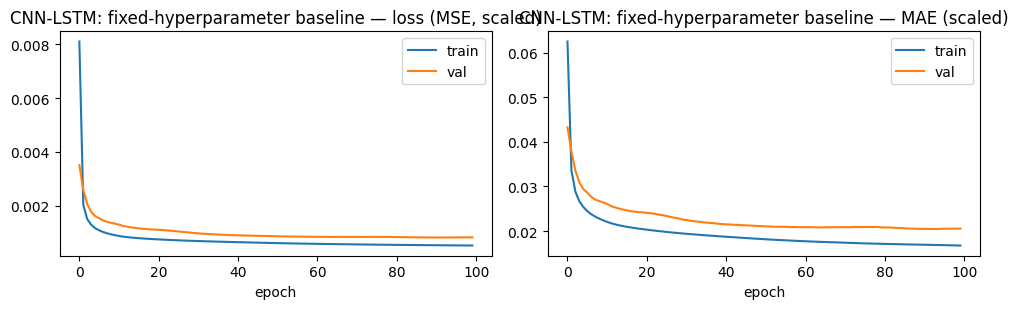

In [11]:
model_baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
    tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL_SIZE, activation="relu", padding="causal"),
    tf.keras.layers.MaxPooling1D(pool_size=POOL_SIZE),
    tf.keras.layers.LSTM(UNITS, return_sequences=False),
    tf.keras.layers.Dense(1),
], name="cnn_lstm_fixed_baseline")

hist_baseline = compile_and_fit(model_baseline, "baseline_fixed_hp", Xm1, ym1, Xv_m1, yv_m1)
plot_history(hist_baseline, "CNN-LSTM: fixed-hyperparameter baseline")

## 6. Define the Search Space

`build_model(hp)` below is a *model-building function*: instead of hard-coded
values, each hyperparameter is drawn from a range or a list of choices via the
`hp` object Keras Tuner passes in. The model is compiled inside this function
too, since the learning rate itself is one of the things being searched.

In [30]:
# def build_model(hp):
#     filters = hp.Int("filters", min_value=16, max_value=64, step=16)
#     kernel_size = hp.Choice("kernel_size", [2, 3, 5])
#     pool_size = hp.Choice("pool_size", [2, 3])
#     lstm_units = hp.Int("lstm_units", min_value=16, max_value=96, step=16)
#     dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.4, step=0.1)
#     learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
#         tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="causal"),
#         tf.keras.layers.MaxPooling1D(pool_size=pool_size),
#         tf.keras.layers.LSTM(lstm_units, return_sequences=False),
#         tf.keras.layers.Dropout(dropout_rate),
#         tf.keras.layers.Dense(1),
#     ])
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss="mse",
#         metrics=["mae"],
#     )
#     return model


# print("Search space: filters in [16,32,48,64], kernel_size in {2,3,5}, pool_size in {2,3}, "
#       "lstm_units in [16..96 step 16], dropout_rate in [0.0..0.4], learning_rate in [1e-4, 1e-2] (log scale)")

#ADDING MORE TUNABLE HYPERPARAMETERS : l2_strength and kernel_regularizer
def build_model(hp):
    filters = hp.Int("filters", min_value=16, max_value=64, step=16)
    kernel_size = hp.Choice("kernel_size", [2, 3, 5])
    pool_size = hp.Choice("pool_size", [2, 3])
    lstm_units = hp.Int("lstm_units", min_value=16, max_value=96, step=16)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.4, step=0.1)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    l2_strength = hp.Choice("l2_strength", [0.0, 1e-5, 1e-4, 1e-3])

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(WINDOW, N_FEATURES)),
        tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="causal"),
        tf.keras.layers.MaxPooling1D(pool_size=pool_size),
        tf.keras.layers.LSTM(lstm_units, return_sequences=False),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1, kernel_regularizer=tf.keras.regularizers.l2(l2_strength)),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model

## 7. Run the Search

`RandomSearch` samples `MAX_TRIALS` hyperparameter combinations, trains each
for `SEARCH_EPOCHS` epochs (deliberately fewer than the final `EPOCHS = 100`,
since the goal here is only to *rank* combinations quickly, not fully train
every one), and tracks each trial's `val_loss`.

In [31]:
MAX_TRIALS = 20
SEARCH_EPOCHS = 30

tuner = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=SEARCH_EPOCHS,
    factor=3,
    directory="kt_search",
    project_name="cnn_lstm_hyperband",
    overwrite=True,
    seed=42,
)


tuner.search(
    Xm1, ym1,
    validation_data=(Xv_m1, yv_m1),
    epochs=SEARCH_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
)

tuner.results_summary(num_trials=3)

Results summary
Results in kt_search/cnn_lstm_hyperband
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 0072 summary
Hyperparameters:
filters: 32
kernel_size: 2
pool_size: 2
lstm_units: 32
dropout_rate: 0.1
learning_rate: 0.0022108968049675453
l2_strength: 0.0
tuner/epochs: 30
tuner/initial_epoch: 10
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0069
Score: 0.0009107955847866833

Trial 0082 summary
Hyperparameters:
filters: 64
kernel_size: 3
pool_size: 2
lstm_units: 80
dropout_rate: 0.30000000000000004
learning_rate: 0.0013638404825740366
l2_strength: 1e-05
tuner/epochs: 30
tuner/initial_epoch: 10
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.0009286955464631319

Trial 0073 summary
Hyperparameters:
filters: 32
kernel_size: 2
pool_size: 2
lstm_units: 80
dropout_rate: 0.0
learning_rate: 0.0007781436518320102
l2_strength: 1e-05
tuner/epochs: 30
tuner/initial_epoch: 10
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0071
Score: 0.00093965424457564

In [34]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Best hyperparameters found:
  filters: 32
  kernel_size: 2
  pool_size: 2
  lstm_units: 32
  dropout_rate: 0.1
  learning_rate: 0.0022108968049675453
  l2_strength: 0.0
  tuner/epochs: 30
  tuner/initial_epoch: 10
  tuner/bracket: 2
  tuner/round: 2
  tuner/trial_id: 0069


In [33]:
print(f"Trials run by Hyperband: {len(tuner.oracle.trials)}")
print(f"Best val_loss: {tuner.oracle.get_best_trials(1)[0].score:.5f}")

Trials run by Hyperband: 90
Best val_loss: 0.00091


### DO NOT RERUN [18] [23]

## 8. Train the Best Model Fully

The tuner only trained each trial for `SEARCH_EPOCHS` to rank them quickly.
Now rebuild the best configuration and train it for the full `EPOCHS = 100`,
same as every other notebook in this set, for a fair final comparison.

Note this uses `fit_only` (not `compile_and_fit`): `tuner.hypermodel.build(best_hp)`
returns a model **already compiled** with its tuned learning rate inside
`build_model()` — recompiling it with `compile_and_fit` would silently reset
that tuned optimizer back to Adam's default learning rate.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 24, 48)         │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,929 (42.69 KB)

 Trainable params: 10,929 (42.69 KB)

 Non-trainable params: 0 (0.00 B)

tuned: ran 100/100 epochs  final val_loss=0.00089  val_mae=0.02130  params=10,929


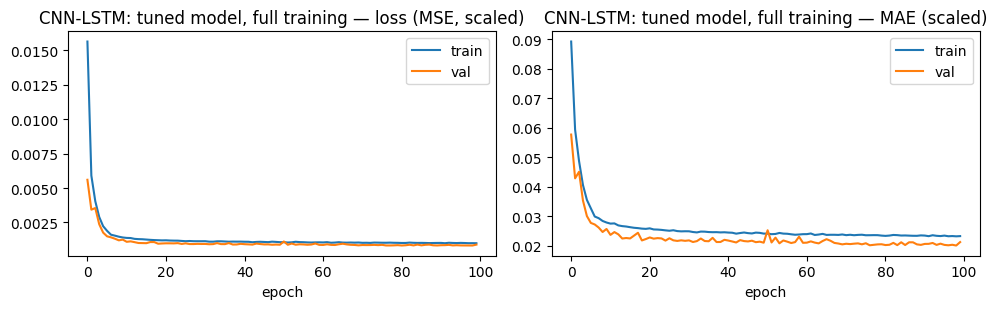

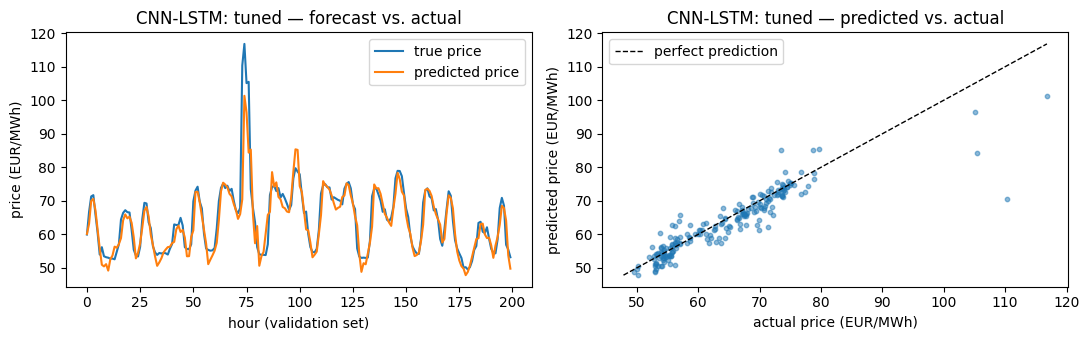

In [18]:
model_tuned = tuner.hypermodel.build(best_hp)
model_tuned.summary()
show_model_diagram(model_tuned, "cnn_lstm_tuned.png")

hist_tuned = fit_only(model_tuned, "tuned", Xm1, ym1, Xv_m1, yv_m1, epochs=EPOCHS)
plot_history(hist_tuned, "CNN-LSTM: tuned model, full training")

pred_tuned = model_tuned.predict(Xv_m1, verbose=0)
plot_point_prediction(yv_m1, pred_tuned, "CNN-LSTM: tuned")

## 9. Baseline vs. Tuned: Side-by-Side

In [19]:
rows = []
for name, model in [("baseline_fixed_hp", model_baseline), ("tuned", model_tuned)]:
    h = history_log[name]
    rows.append({
        "model": name,
        "params": model.count_params(),
        "final_val_loss_mse": h.history["val_loss"][-1],
        "final_val_mae": h.history["val_mae"][-1],
    })

summary_df = pd.DataFrame(rows).set_index("model")
summary_df

,params,final_val_loss_mse,final_val_mae
model,,,
baseline_fixed_hp,8865,0.000822,0.020560
tuned,10929,0.000893,0.021297


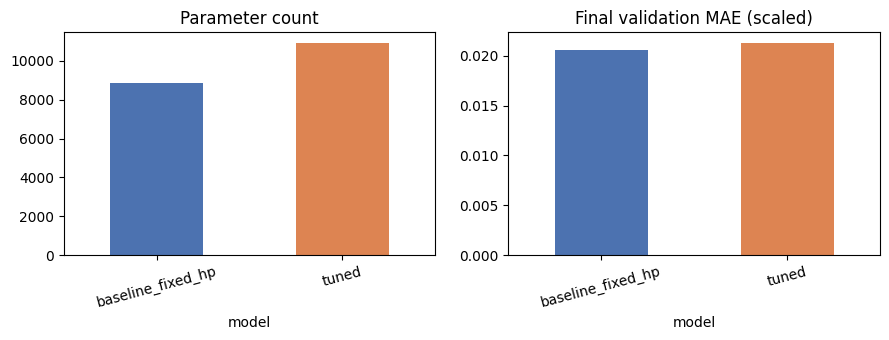

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
summary_df["params"].plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Parameter count")
axes[0].tick_params(axis="x", rotation=15)

summary_df["final_val_mae"].plot.bar(ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Final validation MAE (scaled)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 10. Reflection

- Which hyperparameter(s) does `tuner.results_summary(num_trials=3)` suggest
  mattered most across the top trials — filters, kernel size, LSTM units,
  dropout, or learning rate?
- Did the tuned model beat the fixed-hyperparameter baseline in this notebook?
  Did it also beat the plain-LSTM and baseline-CNN-LSTM numbers from the
  earlier notebooks?
- `MAX_TRIALS = 8` and `SEARCH_EPOCHS = 20` were kept small for speed. If you
  increase both (say, 30 trials / 40 epochs), how much does the best `val_loss`
  improve — and is that improvement worth the extra compute time?

## References

- O'Malley, T. et al., *KerasTuner*, https://keras.io/keras_tuner/
- Bergstra, J. & Bengio, Y. (2012), *Random Search for Hyper-Parameter Optimization*, JMLR.